# Evaluación y Benchmarking de Modelos de Lenguaje

**Duración estimada:** ~2.5 horas  
**Nivel:** Intermedio  
**Requisitos:** haber visto los notebooks 01–05 (NLP básico, modelos de lenguaje, Transformers)

Hasta ahora hemos *entrenado* modelos de lenguaje. Pero hay una pregunta que evitamos cuidadosamente:

> **¿Qué tan bueno es el modelo que acabamos de entrenar?**

Esa pregunta es sorprendentemente difícil. "Bueno" depende de la tarea, del usuario, del costo, e incluso del momento en que se mide (un benchmark de 2019 dice poco de un LLM de 2025). Este notebook recorre **cómo se mide el rendimiento de un modelo de lenguaje**, desde las métricas estadísticas más básicas (perplexity) hasta los benchmarks holísticos modernos (HELM, Chatbot Arena), pasando por las trampas conocidas (contaminación de datos, ley de Goodhart).

Al final de este notebook:

- entenderás la diferencia entre **evaluación intrínseca** y **extrínseca**;
- calcularás a mano *perplexity*, *cross-entropy*, *BLEU*, *ROUGE* y *BERTScore*;
- conocerás los principales benchmarks modernos (MMLU, HellaSwag, GSM8K, HumanEval, MT-Bench…);
- sabrás qué es un *leaderboard* y por qué Chatbot Arena cambió las reglas;
- identificarás los problemas más comunes: **contaminación**, **memorización**, **Goodhart's law** y **sesgos del juez**.

---

## Tabla de contenidos

0. [Instalación e imports](#0)
1. [¿Qué significa evaluar un modelo de lenguaje?](#1)
2. [Métricas intrínsecas: cross-entropy y perplexity](#2)
3. [Métricas para generación: BLEU, ROUGE, METEOR, chrF, BERTScore](#3)
4. [Métricas para clasificación y QA](#4)
5. [Benchmarks clásicos: GLUE, SuperGLUE, SQuAD](#5)
6. [Benchmarks modernos para LLMs: MMLU, HellaSwag, GSM8K, HumanEval…](#6)
7. [Evaluación holística: HELM, Open LLM Leaderboard, Chatbot Arena](#7)
8. [Evaluación humana y LLM-as-a-judge](#8)
9. [Limitaciones y problemas: contaminación, Goodhart, memorización](#9)
10. [Recursos y lecturas](#10)

<a id='0'></a>
---
## 0. Instalación e imports

Usamos algunas librerías estándar para evaluación: `nltk` (BLEU, METEOR), `sacrebleu` (BLEU "oficial" de WMT y chrF), `rouge_score` (ROUGE), `bert_score` (BERTScore con embeddings) y `evaluate` (la API unificada de HuggingFace). Para la sección de perplexity usamos un modelo pequeño en español (`datificate/gpt2-small-spanish`, GPT-2 base reentrenado sobre Wikipedia en español) — si tu red es lenta puedes cambiarlo por `distilgpt2` (inglés) modificando la constante `MODEL_NAME`.

In [1]:
!uv pip install -q torch numpy pandas matplotlib \
    nltk sacrebleu rouge-score bert-score \
    transformers datasets evaluate scikit-learn

In [2]:
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch: {torch.__version__}')
print(f'Device : {device}')

PyTorch: 2.11.0+cu130
Device : cpu


<a id='1'></a>
---
## 1. ¿Qué significa evaluar un modelo de lenguaje?

### 1.1 Dos grandes familias de evaluación

| Tipo                | Pregunta que responde                                  | Ejemplos                                       |
|---------------------|--------------------------------------------------------|------------------------------------------------|
| **Intrínseca**      | ¿Qué tan bien modela el lenguaje en abstracto?         | Perplexity, cross-entropy, bits-per-character  |
| **Extrínseca**      | ¿Qué tan bien resuelve una tarea útil para humanos?    | Accuracy en QA, BLEU en traducción, MMLU       |

Un modelo puede tener **excelente perplexity** y aun así ser inútil para resúmenes, o a la inversa: GPT-4 no necesariamente gana en perplexity pura sobre un corpus específico, pero arrasa en tareas reales.

### 1.2 Tres dimensiones que se mezclan

Cuando alguien dice "el modelo X es mejor", suele referirse a alguna combinación de:

1. **Capacidad** — ¿qué cosas *puede* hacer? (razonamiento, código, traducción, matemáticas).
2. **Calidad** — ¿qué tan bien las hace? (precisión, fluidez, coherencia, factualidad).
3. **Costo y eficiencia** — latencia, throughput, $/1000 tokens, memoria.

Un buen sistema de evaluación intenta cubrir las tres. **HELM** (§7) lo hace explícito.

### 1.3 Reglas de oro

- **Nunca evalúes en datos de entrenamiento.** Esto es trivial decirlo y muy difícil garantizarlo con LLMs entrenados en "todo internet".
- **Una sola métrica nunca basta.** Modelos con la misma BLEU pueden ser radicalmente distintos cualitativamente.
- **El benchmark debe ser representativo** del uso real. Evaluar un modelo médico con MMLU general dice poco.
- **Reporta intervalos de confianza**, no solo promedios. Una diferencia del 0.5% en MMLU rara vez es estadísticamente significativa.
- **Lo que se mide, se optimiza.** Si los desarrolladores saben qué benchmark se usará, lo van a optimizar (a veces involuntariamente). Es la *ley de Goodhart* aplicada a IA (§9).

<a id='2'></a>
---
## 2. Métricas intrínsecas: cross-entropy y perplexity

Son las métricas más antiguas y también las más fundamentales: miden **qué tan bien el modelo predice un texto real**, sin necesidad de ninguna tarea descendente.

### 2.1 Cross-entropy (entropía cruzada)

Dado un corpus de evaluación con tokens $w_1, w_2, \dots, w_N$, la *cross-entropy* por token es:

$$H = -\frac{1}{N}\sum_{i=1}^{N} \log P(w_i \mid w_{<i})$$

Es exactamente la **loss** que minimiza un LLM durante su entrenamiento (en `nats` si usamos `log` natural, en `bits` si usamos `log_2`). Cuanto más pequeña, mejor predice el modelo.

### 2.2 Perplexity

La perplexity es simplemente la exponencial de la cross-entropy:

$$\text{PPL} = \exp(H) = \exp\!\left(-\frac{1}{N}\sum_{i=1}^{N} \log P(w_i \mid w_{<i})\right)$$

**Interpretación intuitiva:** PPL = $k$ significa que el modelo está, en promedio, *tan confundido* como si tuviera que elegir uniformemente entre $k$ opciones en cada paso. Un modelo perfecto tendría PPL = 1; un modelo aleatorio sobre un vocabulario de tamaño $V$ tendría PPL $\approx V$.

**Cuidados:**

- La perplexity depende de la **tokenización**. No se puede comparar directamente PPL entre modelos con tokenizers distintos. Por eso a veces se reporta **bits-per-character (BPC)** o **bits-per-byte (BPB)**, que normalizan por bytes y son tokenizer-agnósticos.
- PPL solo tiene sentido en datos *fuera del entrenamiento*.
- Un modelo con buena PPL no necesariamente sigue instrucciones bien — son cosas distintas.

### 2.3 Bits-per-character (BPC) y bits-per-byte (BPB)

$$\text{BPC} = \frac{H \cdot N_{\text{tokens}}}{N_{\text{caracteres}} \cdot \ln 2}$$

Convierte la cross-entropy total a bits y la divide entre el número de caracteres (o bytes). Es la métrica preferida para comparar modelos con tokenizadores distintos (típica en benchmarks como **The Pile** o **enwik8**).

### 2.4 Cálculo manual sobre un texto

Vamos a calcular la cross-entropy y la perplexity de `gpt2-small-spanish` sobre un texto corto en español, **paso a paso**, para ver de dónde sale el número.

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = 'datificate/gpt2-small-spanish'   # ~125M params, GPT-2 reentrenado en español
# Alternativa en inglés (más liviana ~330MB): MODEL_NAME = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
lm  = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
lm.eval()

texto_eval = (
    'La arquitectura Transformer, presentada en 2017, sustituyó la recurrencia '
    'por mecanismos de auto-atención y hoy es la base de la mayoría de los modelos '
    'de lenguaje modernos.'
)

ids = tok(texto_eval, return_tensors='pt').input_ids.to(device)
print(f'Tokens: {ids.shape[1]}')
print('Primeros tokens:', tok.convert_ids_to_tokens(ids[0][:10].tolist()))

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 149/149 [00:00<00:00, 29406.71it/s]


GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tokens: 35
Primeros tokens: ['La', 'Ġarquitectura', 'ĠTransform', 'er', ',', 'Ġpresentada', 'Ġen', 'Ġ2017', ',', 'ĠsustituyÃ³']


In [4]:
# Cálculo paso a paso de cross-entropy y perplexity
with torch.no_grad():
    logits = lm(ids).logits                  # (1, T, V)

# Para predecir el token i necesitamos los logits de la posición i-1
shift_logits = logits[:, :-1, :].contiguous()
shift_labels = ids[:, 1:].contiguous()

loss = F.cross_entropy(
    shift_logits.view(-1, shift_logits.size(-1)),
    shift_labels.view(-1),
    reduction='mean',
)
ppl = torch.exp(loss)

# Bits-per-character (sin contar el primer token, que no se predice)
n_tokens_pred = shift_labels.numel()
n_chars       = len(texto_eval)
bpc           = (loss.item() * n_tokens_pred) / (n_chars * math.log(2))

print(f'Cross-entropy (nats/token): {loss.item():.4f}')
print(f'Perplexity                : {ppl.item():.2f}')
print(f'Bits-per-character        : {bpc:.4f}')

Cross-entropy (nats/token): 4.4936
Perplexity                : 89.45
Bits-per-character        : 1.2741


### 2.5 Por-token: ¿qué palabras sorprenden al modelo?

Una visualización útil es ver la **log-probabilidad por token**. Las palabras más "sorprendentes" (con mayor `-log P`) suelen ser nombres propios, números, o continuaciones inusuales. Es la base de detectores de texto generado y de auditorías de calidad.

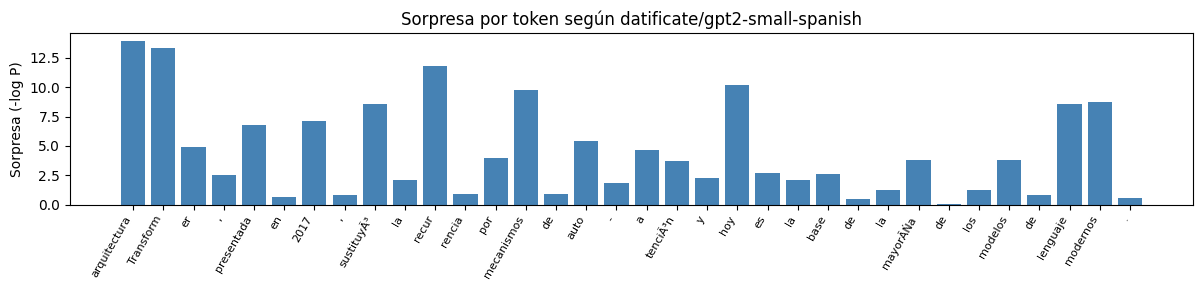


Top-5 tokens más sorprendentes:
        token  surprisal_nats
Ġarquitectura       13.933106
   ĠTransform       13.306026
       Ġrecur       11.842289
         Ġhoy       10.187423
  Ġmecanismos        9.733023


In [5]:
with torch.no_grad():
    log_probs = F.log_softmax(shift_logits, dim=-1)
    token_logp = log_probs.gather(2, shift_labels.unsqueeze(-1)).squeeze(-1)[0].cpu()

tokens = tok.convert_ids_to_tokens(shift_labels[0].cpu().tolist())
surprisal = -token_logp.numpy()              # nats

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(len(tokens)), surprisal, color='steelblue')
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels([t.replace('Ġ', ' ').strip() or t for t in tokens],
                   rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Sorpresa (-log P)')
ax.set_title(f'Sorpresa por token según {MODEL_NAME}')
plt.tight_layout(); plt.show()

df_surp = pd.DataFrame({'token': tokens, 'surprisal_nats': surprisal})
print('\nTop-5 tokens más sorprendentes:')
print(df_surp.nlargest(5, 'surprisal_nats').to_string(index=False))

### 2.6 Perplexity sobre un dataset real (sliding window)

Para textos largos, la PPL se calcula con una **ventana deslizante**: el modelo procesa bloques con un solapamiento (`stride`) para que cada token tenga suficiente contexto. Es el procedimiento estándar (ver tutorial oficial de HuggingFace).

In [6]:
def perplexity_sliding(texto, modelo, tokenizer, max_len=512, stride=256):
    enc = tokenizer(texto, return_tensors='pt')
    input_ids = enc.input_ids.to(device)
    n = input_ids.size(1)

    nlls, n_tokens = [], 0
    prev_end = 0
    for begin in range(0, n, stride):
        end = min(begin + max_len, n)
        trg_len = end - prev_end                       # tokens nuevos en este paso
        ids_chunk = input_ids[:, begin:end]
        targets = ids_chunk.clone()
        targets[:, :-trg_len] = -100                    # ignora el solape

        with torch.no_grad():
            out = modelo(ids_chunk, labels=targets)
            # HF devuelve loss media sobre tokens válidos
            nlls.append(out.loss * trg_len)
            n_tokens += trg_len
        prev_end = end
        if end == n: break

    avg_nll = torch.stack(nlls).sum() / n_tokens
    return torch.exp(avg_nll).item()

texto_largo = (texto_eval + ' ') * 30                  # ~muy repetitivo, baja PPL
print(f'PPL ventana deslizante: {perplexity_sliding(texto_largo, lm, tok):.2f}')

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


PPL ventana deslizante: 1.31


<a id='3'></a>
---
## 3. Métricas para generación: BLEU, ROUGE, METEOR, chrF, BERTScore

Cuando un modelo genera texto (traducción, resumen, respuesta), comparar **producción vs. referencia** humana exacta es tramposo: hay muchas formas correctas de decir lo mismo. Las métricas a continuación son aproximaciones — todas tienen virtudes y defectos.

### 3.1 BLEU — *Bilingual Evaluation Understudy* (Papineni et al., 2002)

Compara $n$-gramas de la salida con los de una o más referencias. Es la métrica histórica de **traducción automática**.

$$\text{BLEU} = BP \cdot \exp\!\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

Donde:
- $p_n$ = precisión de $n$-gramas (con clipping para evitar repeticiones triposas).
- $w_n$ = pesos uniformes ($1/N$, típicamente $N=4$).
- $BP$ = *brevity penalty*, castiga salidas demasiado cortas.

**Limitaciones bien conocidas:**
- Solo precisión, no recall (por eso a veces favorece salidas "seguras").
- No entiende sinónimos: "happy" vs. "joyful" cuentan como distintos.
- Sensible al tokenizer y al *case*. → Por eso **sacreBLEU** se volvió el estándar (tokenización fija y reproducible).

### 3.2 ROUGE — *Recall-Oriented Understudy for Gisting Evaluation* (Lin, 2004)

Hermana orientada a **resúmenes**. La variante más usada es ROUGE-L (longest common subsequence) y ROUGE-N (n-gramas).

$$\text{ROUGE-N (recall)} = \frac{\sum_{\text{n-grama} \in \text{ref}} \text{Match}}{|\text{n-gramas en la referencia}|}$$

Suele reportarse como F1 (precisión + recall).

### 3.3 METEOR

Mejora BLEU usando: stemming ("ran" ↔ "run"), sinónimos (WordNet), y un alineamiento explícito. Correlaciona mejor con juicios humanos a nivel de oración, pero es más complejo y solo está bien soportado en inglés.

### 3.4 chrF — *character n-gram F-score*

BLEU pero a **nivel de caracteres**. Funciona muy bien para idiomas con morfología rica (alemán, español, finés…) donde una variación de sufijo "rompe" un n-grama de palabras pero apenas cambia los caracteres.

### 3.5 BERTScore (Zhang et al., 2019)

En lugar de coincidencias literales, **embebe** ambos textos con BERT y mide similitud coseno entre tokens alineados ávidamente:

$$P_{\text{BERT}} = \frac{1}{|\hat{x}|}\sum_{\hat{x}_j \in \hat{x}} \max_{x_i \in x} \cos(\mathbf{e}_i, \hat{\mathbf{e}}_j)$$

y simétrico para recall. Captura **paráfrasis y sinónimos** y correlaciona mejor con juicios humanos. Costo: necesitas un modelo BERT a la mano.

### 3.6 COMET, BLEURT y *learned metrics*

Métricas que **se entrenan** sobre juicios humanos (DA = direct assessment) y predicen una puntuación. Son el estado del arte actual en traducción (COMET de Unbabel ganó el WMT "metrics shared task" varios años seguidos).

In [7]:
# Ejemplo: una referencia y dos hipótesis
ref      = 'El gato está sentado sobre la alfombra.'
hyp_buena = 'El gato se encuentra encima de la alfombra.'
hyp_mala  = 'Hoy hace mucho calor en la ciudad.'

# --- BLEU (sacrebleu, recomendado) ---
import sacrebleu
bleu_buena = sacrebleu.sentence_bleu(hyp_buena, [ref]).score
bleu_mala  = sacrebleu.sentence_bleu(hyp_mala,  [ref]).score
print(f'BLEU buena : {bleu_buena:5.2f}')
print(f'BLEU mala  : {bleu_mala:5.2f}')

# --- chrF ---
chrf_buena = sacrebleu.sentence_chrf(hyp_buena, [ref]).score
chrf_mala  = sacrebleu.sentence_chrf(hyp_mala,  [ref]).score
print(f'\nchrF buena : {chrf_buena:5.2f}')
print(f'chrF mala  : {chrf_mala:5.2f}')

BLEU buena : 22.32
BLEU mala  :  6.57

chrF buena : 48.37
chrF mala  : 11.02


In [8]:
# --- ROUGE ---
from rouge_score import rouge_scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

for nombre, hyp in [('buena', hyp_buena), ('mala', hyp_mala)]:
    r = scorer.score(ref, hyp)
    print(f'{nombre:5s}  R1={r["rouge1"].fmeasure:.3f}  '
          f'R2={r["rouge2"].fmeasure:.3f}  RL={r["rougeL"].fmeasure:.3f}')

buena  R1=0.533  R2=0.308  RL=0.533
mala   R1=0.143  R2=0.000  RL=0.143


In [9]:
# --- BERTScore ---
# Usa un modelo BERT multilingüe. La primera ejecución descarga ~700MB.
from bert_score import score as bertscore

P, R, F1 = bertscore(
    [hyp_buena, hyp_mala], [ref, ref],
    lang='es',                           # selecciona automáticamente un BERT español
    verbose=False,
)
print(f'BERTScore F1 buena: {F1[0].item():.3f}')
print(f'BERTScore F1 mala : {F1[1].item():.3f}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3915.96it/s]


BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore F1 buena: 0.924
BERTScore F1 mala : 0.746


### 3.7 Lectura del experimento

Observa cómo cambia cada métrica entre la hipótesis buena (paráfrasis correcta) y la mala (oración no relacionada):

- **BLEU** suele ser bajo en *ambas* hipótesis cuando la paráfrasis no comparte n-gramas literales — un problema clásico.
- **chrF** suele ser más generoso con paráfrasis morfológicamente cercanas.
- **ROUGE** funciona mejor cuando hay solapamiento de palabras clave (su sweet-spot es resumen extractivo).
- **BERTScore** captura la similitud semántica y suele dar la mayor diferencia entre buena y mala.

Por eso en evaluación moderna se reportan **varias métricas en conjunto**, y se complementa con humanos cuando hay decisiones importantes.

<a id='4'></a>
---
## 4. Métricas para clasificación y QA

Cuando la salida es una etiqueta (sentimiento, NER, NLI) o una respuesta corta (QA), volvemos al territorio clásico del *machine learning*.

### 4.1 Clasificación

| Métrica                      | Cuándo usarla                                                             |
|------------------------------|---------------------------------------------------------------------------|
| **Accuracy**                 | Clases balanceadas. Engañosa con desbalance.                              |
| **Precision / Recall / F1**  | Clases desbalanceadas o cuando importa más un tipo de error que el otro.  |
| **F1 macro**                 | Promedio simple por clase — todas las clases pesan igual.                 |
| **F1 micro / weighted**      | Pondera por frecuencia de clase.                                          |
| **MCC** (Matthews)           | Clases binarias muy desbalanceadas; rango $[-1, 1]$.                      |
| **AUC-ROC / AUC-PR**         | Cuando se devuelve una probabilidad, no una etiqueta.                     |

### 4.2 Question answering extractivo (estilo SQuAD)

- **Exact Match (EM)**: 1 si la respuesta predicha es idéntica (tras normalizar puntuación, artículos, etc.); 0 en otro caso.
- **F1 sobre tokens**: solapamiento de palabras entre predicción y referencia. Más permisivo que EM.

### 4.3 Multiple-choice (estilo MMLU, ARC, HellaSwag)

El modelo asigna una *log-probabilidad* a cada opción y se elige la mayor. La métrica es **accuracy**. Hay variantes ("normalized accuracy" en HellaSwag) que dividen entre la longitud para no penalizar opciones largas.

In [10]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             matthews_corrcoef, confusion_matrix)

# Caso desbalanceado: 95 negativos, 5 positivos. El modelo dice siempre "negativo".
y_true = [0]*95 + [1]*5
y_pred_trivial = [0]*100
y_pred_decente = [0]*93 + [1]*4 + [0]*3

for nombre, pred in [('trivial', y_pred_trivial), ('decente', y_pred_decente)]:
    acc = accuracy_score(y_true, pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, pred, average='binary', pos_label=1, zero_division=0)
    mcc = matthews_corrcoef(y_true, pred)
    print(f'{nombre:8s}  acc={acc:.2f}  P={p:.2f}  R={r:.2f}  F1={f1:.2f}  MCC={mcc:+.2f}')

trivial   acc=0.95  P=0.00  R=0.00  F1=0.00  MCC=+0.00
decente   acc=0.95  P=0.50  R=0.40  F1=0.44  MCC=+0.42


**Lectura:** el clasificador trivial tiene 95% de accuracy *y un MCC de 0* — útil de detectar. La accuracy sola te engañaría completamente.

### 4.4 Exact Match y F1 para QA

In [11]:
import re, string
from collections import Counter

def normalize(s):
    s = s.lower()
    s = re.sub(r'\b(a|an|the|el|la|los|las|un|una)\b', ' ', s)   # artículos
    s = ''.join(c for c in s if c not in string.punctuation)
    return ' '.join(s.split())

def exact_match(pred, gold):
    return int(normalize(pred) == normalize(gold))

def f1_qa(pred, gold):
    p_tok, g_tok = normalize(pred).split(), normalize(gold).split()
    if not p_tok or not g_tok:
        return int(p_tok == g_tok)
    common = Counter(p_tok) & Counter(g_tok)
    n = sum(common.values())
    if n == 0: return 0.0
    prec = n / len(p_tok); rec = n / len(g_tok)
    return 2 * prec * rec / (prec + rec)

ejemplos = [
    ('La capital de Francia es París', 'París'),
    ('París',                          'París'),
    ('Madrid',                         'París'),
]
for pred, gold in ejemplos:
    print(f'pred="{pred}"  gold="{gold}"  EM={exact_match(pred, gold)}  '
          f'F1={f1_qa(pred, gold):.2f}')

pred="La capital de Francia es París"  gold="París"  EM=0  F1=0.33
pred="París"  gold="París"  EM=1  F1=1.00
pred="Madrid"  gold="París"  EM=0  F1=0.00


<a id='5'></a>
---
## 5. Benchmarks clásicos: GLUE, SuperGLUE, SQuAD

Los benchmarks de "primera generación" (~2017–2019) fueron diseñados para **modelos pre-LLM** (BERT y compañía). Hoy están casi saturados, pero entender su lógica es clave porque marcaron el camino.

### 5.1 GLUE (Wang et al., 2018)

*General Language Understanding Evaluation*. Una colección de **9 tareas** muy distintas, cada una con su métrica:

| Tarea     | Tipo                              | Métrica          |
|-----------|-----------------------------------|------------------|
| CoLA      | aceptabilidad gramatical          | MCC              |
| SST-2     | sentimiento (binario)             | accuracy         |
| MRPC      | paráfrasis                        | F1 / accuracy    |
| STS-B     | similitud semántica continua      | Pearson / Spearman |
| QQP       | paráfrasis (Quora)                | F1 / accuracy    |
| MNLI      | inferencia textual (3 clases)     | accuracy         |
| QNLI      | QA convertido a NLI               | accuracy         |
| RTE       | inferencia (datos pequeños)       | accuracy         |
| WNLI      | resolución de coreferencia        | accuracy         |

El **GLUE score** es el promedio. Cuando BERT lo lanzó (2018), el SOTA estaba en ~70; en 2020 ya superaba los 90 — los humanos en GLUE están alrededor de 87.

### 5.2 SuperGLUE (Wang et al., 2019)

Versión "difícil" para evitar la saturación: tareas más exigentes (BoolQ, CB, COPA, MultiRC, ReCoRD, RTE, WiC, WSC). En 2025 también está prácticamente saturado.

### 5.3 SQuAD 1.1 / 2.0

*Stanford Question Answering Dataset*. Dado un párrafo de Wikipedia, responder a una pregunta extrayendo un span del párrafo.

- **SQuAD 1.1**: toda pregunta tiene respuesta.
- **SQuAD 2.0**: introduce **preguntas sin respuesta** — el modelo debe abstenerse. Mucho más realista.

Métricas: **EM** y **F1** (ver §4.4).

### 5.4 Otros clásicos

- **WMT** (Workshop on Machine Translation): traducción, métrica BLEU/chrF/COMET.
- **CoNLL-2003**: NER en inglés y alemán.
- **CNN/DailyMail**: resumen abstractivo, métrica ROUGE.
- **XNLI**: inferencia multilingüe (15 idiomas).

In [12]:
# Cargamos un puñado de ejemplos de SST-2 (sentimiento) para ilustrar
from datasets import load_dataset

try:
    sst2 = load_dataset('glue', 'sst2', split='validation[:5]')
    for ex in sst2:
        label = 'pos' if ex['label'] == 1 else 'neg'
        print(f'[{label}]  {ex["sentence"].strip()}')
except Exception as e:
    print('No se pudo descargar (¿sin internet?):', e)

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating train split: 100%|██████████| 67349/67349 [00:00<00:00, 3323789.01 examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating validation split: 100%|██████████| 872/872 [00:00<00:00, 613457.41 examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Generating test split: 100%|██████████| 1821/1821 [00:00<00:00, 1114360.60 examples/s]

[pos]  it 's a charming and often affecting journey .
[neg]  unflinchingly bleak and desperate
[pos]  allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker .
[pos]  the acting , costumes , music , cinematography and sound are all astounding given the production 's austere locales .
[neg]  it 's slow -- very , very slow .


<a id='6'></a>
---
## 6. Benchmarks modernos para LLMs

Los LLMs actuales necesitaron benchmarks nuevos: con tareas más difíciles, sin tanta dependencia del fine-tuning, y con énfasis en evaluación **zero-shot** y **few-shot**.

### 6.1 MMLU — *Massive Multitask Language Understanding* (Hendrycks et al., 2020)

57 tareas de opción múltiple (4 opciones) que cubren 57 dominios: matemáticas, derecho, medicina, historia, ética, ingeniería… Es el benchmark de **conocimiento general** por excelencia.

- **Tamaño**: ~15.000 preguntas.
- **Métrica**: accuracy promedio entre tareas.
- **Humano experto**: ~89.8% (estimado).
- **Estado en 2025**: los LLMs frontera (GPT-4o, Claude 4, Gemini 2) están ya por encima del experto humano. Han surgido versiones más duras: **MMLU-Pro** (10 opciones, preguntas más razonadas) y **GPQA** ("Google-Proof"\: PhDs en su dominio aciertan ~65%, no expertos con Google ~34%).

### 6.2 HellaSwag (Zellers et al., 2019)

Sentido común: dada una situación, elegir la continuación más plausible entre 4. Las opciones erróneas se generan adversarialmente para que parezcan plausibles.

- Mide **razonamiento de sentido común**.
- Métrica: accuracy normalizada por longitud de la opción.

### 6.3 ARC — *AI2 Reasoning Challenge*

Preguntas científicas de exámenes escolares (3.°–9.°). Dos splits:
- **Easy**: el modelo puede acertar con recuperación simple.
- **Challenge**: requieren razonamiento, no solo memorización.

### 6.4 TruthfulQA (Lin et al., 2021)

Pregunta cosas donde los humanos suelen equivocarse por mitos populares ("¿qué pasa si te tragas chicle?"). Un modelo entrenado en internet puede memorizar la *mentira común* — TruthfulQA premia las respuestas correctas, no las populares.

Mide **veracidad** y **resistencia a mitos**, no conocimiento bruto.

### 6.5 GSM8K (Cobbe et al., 2021)

8.500 problemas matemáticos de primaria con resolución paso a paso. Métrica: accuracy en la respuesta numérica final.

Es el benchmark canónico para medir **razonamiento aritmético encadenado**. Fue donde el *chain-of-thought prompting* ("piensa paso a paso") mostró saltos enormes.

Para modelos de 2025 ya está saturado → han aparecido **MATH** (problemas de competencia, mucho más duros) y **AIME** (olimpiadas).

### 6.6 HumanEval / MBPP — código

- **HumanEval** (OpenAI, 2021): 164 problemas de programación; el modelo escribe una función Python y se ejecuta contra unit tests. Métrica: **pass@k** = probabilidad de que al menos una de $k$ muestras pase los tests.
- **MBPP** (Google): ~1000 problemas similares.
- Modernos: **SWE-bench** (resolver bugs reales de GitHub), **LiveCodeBench** (problemas de competencias recientes para evitar contaminación).

### 6.7 BIG-bench (Google, 2022)

*Beyond the Imitation Game*: 200+ tareas colaborativas, muchas raras (ajedrez, navaja de Ockham, geometría no euclidiana…). Versión reducida y curada: **BIG-bench Hard (BBH)**, 23 tareas donde los modelos de 2022 fallaban.

### 6.8 Otros relevantes

| Benchmark        | Mide                                              |
|------------------|---------------------------------------------------|
| **DROP**         | razonamiento numérico sobre párrafos              |
| **WinoGrande**   | resolución de pronombres / sentido común          |
| **NaturalQuestions** | QA open-domain                                |
| **MGSM**         | GSM8K traducido a 10 idiomas (multilingüe)        |
| **AGIEval**      | exámenes humanos reales (LSAT, SAT, gaokao…)      |
| **MT-Bench**     | conversaciones multi-turno juzgadas por GPT-4     |
| **IFEval**       | seguimiento de instrucciones verificable          |

In [13]:
# Mini-evaluación tipo MMLU/HellaSwag: log-probabilidad por opción.
# El benchmark real tiene miles de preguntas; aquí hacemos 3 a mano para ilustrar.
preguntas = [
    {
        'prompt'  : 'Pregunta: ¿Cuál es la capital de Francia?\nRespuesta:',
        'opciones': [' París', ' Londres', ' Berlín', ' Madrid'],
        'gold'    : 0,
    },
    {
        'prompt'  : 'Pregunta: ¿Cuánto es 2 + 2?\nRespuesta:',
        'opciones': [' cuatro', ' cinco', ' tres', ' siete'],
        'gold'    : 0,
    },
    {
        'prompt'  : 'Pregunta: ¿A qué temperatura hierve el agua a presión normal?\nRespuesta:',
        'opciones': [' 100 grados Celsius', ' 50 grados Celsius',
                     ' 200 grados Celsius', ' 0 grados Celsius'],
        'gold'    : 0,
    },
]

def logprob_de_continuacion(prompt, continuacion, model, tokenizer):
    """Suma de log-probs que el modelo asigna a `continuacion` dado `prompt`."""
    enc_full = tokenizer(prompt + continuacion, return_tensors='pt').input_ids.to(device)
    enc_pre  = tokenizer(prompt,                return_tensors='pt').input_ids.to(device)
    n_pre, n_full = enc_pre.size(1), enc_full.size(1)

    with torch.no_grad():
        logits = model(enc_full).logits             # (1, T, V)
    log_probs = F.log_softmax(logits[0], dim=-1)

    # log-prob de cada token de la continuación
    cont_ids  = enc_full[0, n_pre:n_full]
    pred_logp = log_probs[n_pre - 1 : n_full - 1]    # logits que predicen esos tokens
    return pred_logp.gather(1, cont_ids.unsqueeze(-1)).sum().item()

aciertos = 0
for ex in preguntas:
    scores = [logprob_de_continuacion(ex['prompt'], op, lm, tok) for op in ex['opciones']]
    pred   = int(np.argmax(scores))
    ok     = pred == ex['gold']
    aciertos += ok
    print(f'{"OK " if ok else "X  "}gold={ex["opciones"][ex["gold"]].strip()}  '
          f'pred={ex["opciones"][pred].strip()}')
    for op, s in zip(ex['opciones'], scores):
        print(f'   {op:30s}  logp={s:+.2f}')

print(f'\nAccuracy mini-benchmark: {aciertos}/{len(preguntas)}')

OK gold=París  pred=París
    París                          logp=-7.09
    Londres                        logp=-10.17
    Berlín                         logp=-10.25
    Madrid                         logp=-8.49


X  gold=cuatro  pred=tres
    cuatro                         logp=-10.45
    cinco                          logp=-11.26
    tres                           logp=-9.78
    siete                          logp=-12.48


X  gold=100 grados Celsius  pred=0 grados Celsius
    100 grados Celsius             logp=-13.14
    50 grados Celsius              logp=-12.14
    200 grados Celsius             logp=-14.36
    0 grados Celsius               logp=-11.59

Accuracy mini-benchmark: 1/3


Esta es **exactamente** la mecánica con la que se evalúa MMLU, HellaSwag o ARC en los leaderboards: para cada pregunta de opción múltiple, se calcula la log-probabilidad que el modelo asigna a cada continuación posible y se elige la mayor. La única diferencia es que el benchmark real tiene miles de preguntas y, a veces, *normaliza* por longitud o aplica *few-shot* (incluyendo ejemplos previos en el prompt).

<a id='7'></a>
---
## 7. Evaluación holística: HELM, Open LLM Leaderboard, Chatbot Arena

Una métrica nunca alcanza. Estos *frameworks* combinan muchas pruebas y publican rankings.

### 7.1 HELM — *Holistic Evaluation of Language Models* (Stanford, 2022)

Propone evaluar 7 dimensiones simultáneamente, no solo "accuracy":

1. **Accuracy**
2. **Calibration** (¿la confianza del modelo refleja su acierto?)
3. **Robustness** (¿se rompe con errores tipográficos o paráfrasis?)
4. **Fairness** (sesgos por género, raza, dialecto)
5. **Bias / Toxicity**
6. **Efficiency** (latencia, costo)
7. **General capabilities** (cobertura amplia)

Es el intento más serio de evaluar **trade-offs** y no solo la cima de un leaderboard.

### 7.2 Open LLM Leaderboard (HuggingFace)

Inicialmente combinaba 6 benchmarks (MMLU, HellaSwag, ARC, TruthfulQA, Winogrande, GSM8K). En su segunda versión (2024+) se renovó por completo a benchmarks **más difíciles y menos contaminados**: MMLU-Pro, GPQA, MUSR, IFEval, BBH, MATH-Lvl-5.

Es la referencia abierta para comparar modelos open-source de manera reproducible.

### 7.3 LMSYS Chatbot Arena (2023+)

Cambia las reglas: en lugar de un benchmark cerrado, **los usuarios** chatean con dos modelos anónimos en paralelo y votan cuál respondió mejor. Con suficientes votos se calcula un ranking **Elo** (como en ajedrez).

Ventajas:
- Imposible de "sobreajustar" — los prompts son orgánicos y diversos.
- Refleja preferencia humana real, no proxy de benchmarks.

Limitaciones:
- Sesgo a respuestas largas / con formato bonito.
- Los usuarios no son evaluadores expertos en todos los dominios.
- Difícil reproducir resultados.

Hoy es probablemente la **señal más confiable** sobre la calidad percibida de un LLM en uso conversacional.

### 7.4 Otros importantes

- **MT-Bench**: 80 prompts multi-turno, juzgados por GPT-4 (LLM-as-a-judge — ver §8).
- **Arena-Hard**: subconjunto difícil de prompts de Chatbot Arena.
- **AlpacaEval**: comparación pairwise vs. un baseline (GPT-4-turbo), juez automático.

In [14]:
# Pequeña simulación de cómo Chatbot Arena calcula Elo a partir de votos
def actualizar_elo(ra, rb, resultado_a, K=32):
    """resultado_a = 1 si gana A, 0 si gana B, 0.5 empate."""
    ea = 1 / (1 + 10 ** ((rb - ra) / 400))
    return ra + K * (resultado_a - ea), rb + K * ((1 - resultado_a) - (1 - ea))

# Simulación: 4 modelos, 2000 partidas con probabilidades "reales" desconocidas
rng = np.random.default_rng(0)
modelos = ['model_A', 'model_B', 'model_C', 'model_D']
skill_real = {'model_A': 1500, 'model_B': 1400, 'model_C': 1300, 'model_D': 1200}
elo = {m: 1200 for m in modelos}

for _ in range(2000):
    a, b = rng.choice(modelos, size=2, replace=False)
    p_a = 1 / (1 + 10 ** ((skill_real[b] - skill_real[a]) / 400))
    res = 1 if rng.random() < p_a else 0
    elo[a], elo[b] = actualizar_elo(elo[a], elo[b], res)

print('Elo estimado tras 2000 partidas (vs. el real entre paréntesis):')
for m in sorted(elo, key=lambda x: -elo[x]):
    print(f'  {m}: {elo[m]:.0f}   (real: {skill_real[m]})')

Elo estimado tras 2000 partidas (vs. el real entre paréntesis):
  model_A: 1322   (real: 1500)
  model_B: 1208   (real: 1400)
  model_C: 1187   (real: 1300)
  model_D: 1083   (real: 1200)


<a id='8'></a>
---
## 8. Evaluación humana y LLM-as-a-judge

### 8.1 Evaluación humana

El gold standard cuando lo demás no alcanza. Modalidades:

- **Likert**: el evaluador puntúa cada respuesta en una escala (1–5, 1–7).
- **Pairwise**: "¿cuál de estas dos respuestas es mejor?". Mucho más confiable que Likert (los humanos son malos asignando números absolutos).
- **Rúbrica**: criterios específicos (corrección, fluidez, utilidad, seguridad) puntuados por separado.
- **Win-rate**: porcentaje de comparaciones en que el modelo A vence al modelo B.

**Costo:** $$$. Para benchmarks con miles de prompts, evaluar con humanos puede costar decenas de miles de dólares y semanas de coordinación.

**Confiabilidad:** se mide con **inter-annotator agreement** (Cohen's $\kappa$, Fleiss', acuerdo crudo). Por debajo de $\kappa = 0.4$ los humanos no se ponen de acuerdo y la métrica es ruido.

### 8.2 LLM-as-a-judge

Usar a otro LLM (típicamente GPT-4 o Claude) como juez de las salidas. Es **mucho más barato** y suficiente en muchos casos (Zheng et al., 2023, *MT-Bench*).

**Pros**
- Escalable y rápido.
- Correlaciona ~80% con humanos en preferencias generales.
- Reproducible si fijamos el modelo juez y la temperatura.

**Sesgos conocidos** (¡importantes!):
- **Position bias**: el juez tiende a preferir la primera opción (mitigación: alternar y promediar).
- **Verbosity bias**: prefiere respuestas largas.
- **Self-preference bias**: GPT-4 prefiere salidas de GPT-4; Claude las suyas. → Si juzgas, no juzgues con un familiar tuyo.
- **Sycophancy**: el juez está sesgado hacia respuestas que reflejan el prompt.

Buenas prácticas:
- **Pairwise** > scoring absoluto.
- Alternar el orden de las dos respuestas y promediar.
- Pedir el razonamiento ANTES del veredicto (no al revés).
- Tener un *eval set* humano de calibración.

### 8.3 Plantilla típica de prompt para juzgar

In [15]:
PLANTILLA_JUEZ = """Eres un evaluador imparcial. Te daré una pregunta y dos respuestas
(A y B). Decide cuál es mejor según: corrección, claridad, completitud y utilidad.

Pregunta:
{pregunta}

Respuesta A:
{respuesta_a}

Respuesta B:
{respuesta_b}

Razona brevemente y termina con UNA SOLA línea con uno de:
[[A]]   (A es claramente mejor)
[[B]]   (B es claramente mejor)
[[T]]   (empate)
"""

# Ejemplo de uso (no llamamos a la API aquí, solo mostramos la plantilla)
ejemplo = PLANTILLA_JUEZ.format(
    pregunta='¿Por qué se usa softmax en la última capa de un clasificador?',
    respuesta_a='Porque sí.',
    respuesta_b='Softmax convierte logits en una distribución de probabilidad sobre '
                'las clases (suma 1, valores en [0,1]), lo que permite usar cross-entropy '
                'y obtener una salida interpretable como probabilidad de cada clase.',
)
print(ejemplo)

Eres un evaluador imparcial. Te daré una pregunta y dos respuestas
(A y B). Decide cuál es mejor según: corrección, claridad, completitud y utilidad.

Pregunta:
¿Por qué se usa softmax en la última capa de un clasificador?

Respuesta A:
Porque sí.

Respuesta B:
Softmax convierte logits en una distribución de probabilidad sobre las clases (suma 1, valores en [0,1]), lo que permite usar cross-entropy y obtener una salida interpretable como probabilidad de cada clase.

Razona brevemente y termina con UNA SOLA línea con uno de:
[[A]]   (A es claramente mejor)
[[B]]   (B es claramente mejor)
[[T]]   (empate)



Para evitar el *position bias*, en producción se evalúan **ambos órdenes** (A,B) y (B,A) y se promedia. Si el juez cambia de opinión al cambiar el orden, es señal de empate o de sesgo.

<a id='9'></a>
---
## 9. Limitaciones y problemas

Cualquier benchmark suficientemente popular acaba siendo víctima de su propio éxito. Estos son los problemas con los que **siempre** hay que contar.

### 9.1 Contaminación de datos (*data contamination*)

Si el modelo vio el benchmark durante el preentrenamiento, su accuracy es inflada — está *recordando*, no generalizando. Los LLMs frontera entrenan con grandes porciones de internet, donde MMLU y SQuAD aparecen literalmente.

**Mitigaciones:**
- Benchmarks **dinámicos** (LiveCodeBench, LiveBench) que se actualizan con problemas posteriores al cutoff.
- Verificar contaminación con **n-gram overlap** entre benchmark y datos de entrenamiento.
- Test sets **privados** o **encriptados** (como en algunas competiciones de Kaggle).
- *Holdout* genuino: AIME 2025, GPQA reciente, etc.

### 9.2 Ley de Goodhart

> *Cuando una medida se convierte en objetivo, deja de ser una buena medida.*

Si optimizas MMLU, mejorarás MMLU — pero **no necesariamente** la capacidad subyacente que MMLU intenta medir. La saturación rápida de un benchmark suele ser síntoma de Goodhart.

### 9.3 Memorización vs. generalización

Diferencia sutil con contaminación: incluso datos *no contaminados* pueden inducir respuestas memorizadas (ej. fechas históricas, hechos triviales). Lo que medimos no es siempre razonamiento — a veces es un buen recall.

### 9.4 Fragilidad de las métricas

- Pequeños cambios en el prompt o en el formato cambian la accuracy varios puntos.
- BLEU/ROUGE penalizan paráfrasis correctas.
- Exact-Match falla si el modelo dice "Paris" cuando se esperaba "Paris.".

Por eso es buena práctica reportar **varios runs con prompts distintos** y promediar.

### 9.5 Sesgos del evaluador

Tanto humanos como LLMs traen sesgos: posición, longitud, formato, simpatía. Importante en producción.

### 9.6 Validez de constructo

¿La métrica realmente mide lo que dice medir? Una alta puntuación en TruthfulQA no garantiza un modelo "veraz" en producción — solo un modelo bueno en *ese conjunto específico de preguntas*. Lo mismo aplica a *safety*, *alignment*, *bias*…

### 9.7 Una checklist práctica antes de creerle a un benchmark

1. ¿El conjunto de evaluación está separado del entrenamiento? ¿Cómo se garantiza?
2. ¿Se reportan múltiples métricas, no solo una?
3. ¿Hay intervalos de confianza o desviación estándar?
4. ¿El benchmark es reciente o ya está saturado?
5. ¿El protocolo (prompt, few-shot, decoding) es público y reproducible?
6. ¿Quién creó el benchmark? ¿Tiene incentivos que sesgen el resultado?
7. ¿La distribución del test corresponde al uso real que vas a darle al modelo?

In [16]:
# Mini-demostración de fragilidad: la misma pregunta con dos formatos
prompts = [
    'Q: What is 2+2?\nA:',
    '¿Cuánto es 2+2?\nRespuesta:',
    'The answer to 2+2 is',
]

for p in prompts:
    enc = tok(p, return_tensors='pt').input_ids.to(device)
    with torch.no_grad():
        out = lm.generate(enc, max_new_tokens=8, do_sample=False,
                          pad_token_id=tok.eos_token_id)
    cont = tok.decode(out[0][enc.size(1):], skip_special_tokens=True)
    print(f'prompt: {p!r}')
    print(f'   →    {cont!r}')
    print()

prompt: 'Q: What is 2+2?\nA:'
   →    ' ¿Qué es 2+2?\n'



prompt: '¿Cuánto es 2+2?\nRespuesta:'
   →    '\n\n\n\n\n\n\n\n'



prompt: 'The answer to 2+2 is'
   →    ' a when I want to the'



Mismo modelo, misma pregunta esencial, **respuestas distintas** según el formato del prompt. Esa fragilidad es la razón por la que la mayoría de papers serios reportan resultados promediados sobre múltiples plantillas de prompt y semillas.

<a id='10'></a>
---
## 10. Recursos y lecturas

### Papers fundamentales
- Papineni et al. (2002), *BLEU: a Method for Automatic Evaluation of Machine Translation*.
- Lin (2004), *ROUGE: A Package for Automatic Evaluation of Summaries*.
- Wang et al. (2018), *GLUE* — [arXiv:1804.07461](https://arxiv.org/abs/1804.07461).
- Wang et al. (2019), *SuperGLUE* — [arXiv:1905.00537](https://arxiv.org/abs/1905.00537).
- Hendrycks et al. (2020), *Measuring Massive Multitask Language Understanding (MMLU)* — [arXiv:2009.03300](https://arxiv.org/abs/2009.03300).
- Zellers et al. (2019), *HellaSwag* — [arXiv:1905.07830](https://arxiv.org/abs/1905.07830).
- Cobbe et al. (2021), *GSM8K* — [arXiv:2110.14168](https://arxiv.org/abs/2110.14168).
- Chen et al. (2021), *Codex / HumanEval* — [arXiv:2107.03374](https://arxiv.org/abs/2107.03374).
- Lin et al. (2021), *TruthfulQA* — [arXiv:2109.07958](https://arxiv.org/abs/2109.07958).
- Liang et al. (2022), *HELM: Holistic Evaluation of Language Models* — [arXiv:2211.09110](https://arxiv.org/abs/2211.09110).
- Zheng et al. (2023), *MT-Bench / LLM-as-a-Judge* — [arXiv:2306.05685](https://arxiv.org/abs/2306.05685).
- Zhang et al. (2019), *BERTScore* — [arXiv:1904.09675](https://arxiv.org/abs/1904.09675).

### Plataformas y leaderboards
- **HuggingFace Open LLM Leaderboard** — modelos open-source, reproducible.
- **LMSYS Chatbot Arena** — Elo basado en votos humanos.
- **HELM (Stanford CRFM)** — evaluación holística.
- **EleutherAI lm-evaluation-harness** — la herramienta open-source estándar para correr benchmarks.
- **HuggingFace `evaluate`** — API unificada para BLEU, ROUGE, BERTScore, etc.

### Tutoriales y artículos recomendados
- *Perplexity of fixed-length models* — docs oficiales de HuggingFace.
- *A Survey on Evaluation of Large Language Models* (Chang et al., 2023).
- *Holistic Evaluation of Language Models* (HELM blog, Stanford).

---

## Ejercicios sugeridos

1. **Compara perplexity** del `MiniGPT` que entrenaste en el notebook 05 con `distilgpt2` sobre el mismo texto. ¿Qué te dice la diferencia?
2. **Implementa BLEU desde cero** (n-gramas + brevity penalty) y compáralo con `sacrebleu` en 10 ejemplos.
3. **Construye un mini-MMLU** propio con 20 preguntas tuyas en español, evalúa `distilgpt2` y un modelo más grande (`gpt2-large` o algún Llama abierto). Reporta accuracy y desviación.
4. **Implementa LLM-as-a-judge** llamando a una API (Claude/OpenAI) sobre 20 pares de respuestas. Mide cuánto cambia el veredicto al invertir el orden (position bias).
5. **Detección de contaminación**: toma 50 preguntas de MMLU y haz un *substring search* contra un texto público (Wikipedia ES). ¿Cuántas aparecen literalmente?
6. **Calibración**: para una tarea de clasificación, grafica la *reliability diagram* (probabilidad predicha vs. accuracy real). ¿Tu modelo está sobreconfiado?